In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)


In [4]:
customers_df = pd.read_csv("raw_files/customers.csv")
customers_df

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.000,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.000,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.000,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.000,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.000,1.000,ACTIVE,Regularly,52.000,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...
...,...,...,...,...,...,...,...
1371975,ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e474...,NaN,NaN,ACTIVE,NONE,24.000,7aa399f7e669990daba2d92c577b52237380662f36480b...
1371976,ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab5...,NaN,NaN,ACTIVE,NONE,21.000,3f47f1279beb72215f4de557d950e0bfa73789d24acb5e...
1371977,ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1...,1.000,1.000,ACTIVE,Regularly,21.000,4563fc79215672cd6a863f2b4bf56b8f898f2d96ed590e...
1371978,ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38...,1.000,1.000,ACTIVE,Regularly,18.000,8892c18e9bc3dca6aa4000cb8094fc4b51ee8db2ed14d7...


In [5]:
articles_df = pd.read_csv("raw_files/articles.csv")
articles_df

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105537,953450001,953450,5pk regular Placement1,302,Socks,Socks & Tights,1010014,Placement print,9,Black,4,Dark,5,Black,7188,Socks Bin,F,Menswear,3,Menswear,26,Men Underwear,1021,Socks and Tights,Socks in a fine-knit cotton blend with a small...
105538,953763001,953763,SPORT Malaga tank,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1919,Jersey,A,Ladieswear,1,Ladieswear,2,H&M+,1005,Jersey Fancy,Loose-fitting sports vest top in ribbed fast-d...
105539,956217002,956217,Cartwheel dress,265,Dress,Garment Full body,1010016,Solid,9,Black,4,Dark,5,Black,1641,Jersey,A,Ladieswear,1,Ladieswear,18,Womens Trend,1005,Jersey Fancy,"Short, A-line dress in jersey with a round nec..."
105540,957375001,957375,CLAIRE HAIR CLAW,72,Hair clip,Accessories,1010016,Solid,9,Black,4,Dark,5,Black,3946,Small Accessories,D,Divided,2,Divided,52,Divided Accessories,1019,Accessories,Large plastic hair claw.


In [6]:
transaction_train_df = pd.read_csv("raw_files/transactions_train.csv")
transaction_train_df

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.051,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.017,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.017,2
...,...,...,...,...,...
31788319,2020-09-22,fff2282977442e327b45d8c89afde25617d00124d0f999...,929511001,0.059,2
31788320,2020-09-22,fff2282977442e327b45d8c89afde25617d00124d0f999...,891322004,0.042,2
31788321,2020-09-22,fff380805474b287b05cb2a7507b9a013482f7dd0bce0e...,918325001,0.043,1
31788322,2020-09-22,fff4d3a8b1f3b60af93e78c30a7cb4cf75edaf2590d3e5...,833459002,0.007,1


In [7]:
print("Transactions:", transaction_train_df.shape)
print("Customers:", customers_df.shape)
print("Articles:", articles_df.shape)

Transactions: (31788324, 5)
Customers: (1371980, 7)
Articles: (105542, 25)


In [ ]:
transaction_train_df = transaction_train_df.dropna(subset=["customer_id"])
transaction_train_df["customer_id"].nunique()

1362281

: 

В датасете отсутствуют пропуски customer_id.

In [8]:
transaction_train_df["t_dat"].min(), transaction_train_df["t_dat"].max()

('2018-09-20', '2020-09-22')

Датасет содержит транзакции за период с 2018-09-20 по 2020-09-22. Крайние месяцы могут быть неполными, это будет учтено при формировании когорт.

In [9]:
n_customers = transaction_train_df["customer_id"].nunique()
n_transactions = len(transaction_train_df)

print(f"Число уникальных клиентов: {n_customers:,}")
print(f"Число транзакций: {n_transactions:,}")

Число уникальных клиентов: 1,362,281
Число транзакций: 31,788,324


Вычислим количество покупок на одного клиента за все время с 2018-09-20 по 2020-09-22

In [18]:
purchases_per_customer.describe()

count   1362281.000
mean         23.335
std          39.242
min           1.000
25%           3.000
50%           9.000
75%          27.000
max        1895.000
dtype: float64

In [11]:
transaction_train_df["customer_id"].nunique()

1362281

Усреднённые метрики плохо отражают поведение типичного клиента, поэтому дальнейший анализ удержания проведем в разрезе когорт и сегментов.

In [13]:
one_time_share = (purchases_per_customer == 1).mean()
print(f"Доля клиентов с одной покупкой: {one_time_share:.1%}")

Доля клиентов с одной покупкой: 9.7%


In [14]:
purchases_per_customer.quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.500     9.000
0.750    27.000
0.900    60.000
0.950    91.000
0.990   187.000
dtype: float64

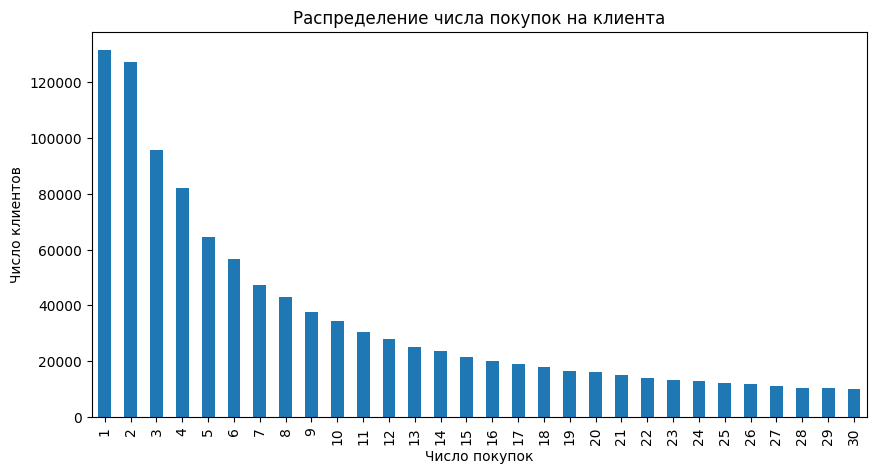

In [15]:
counts = purchases_per_customer.value_counts().sort_index()
plt.figure(figsize = (10, 5))
counts.loc[1:30].plot(kind="bar")
plt.title("Распределение числа покупок на клиента")
plt.xlabel("Число покупок")
plt.ylabel("Число клиентов")
plt.show()

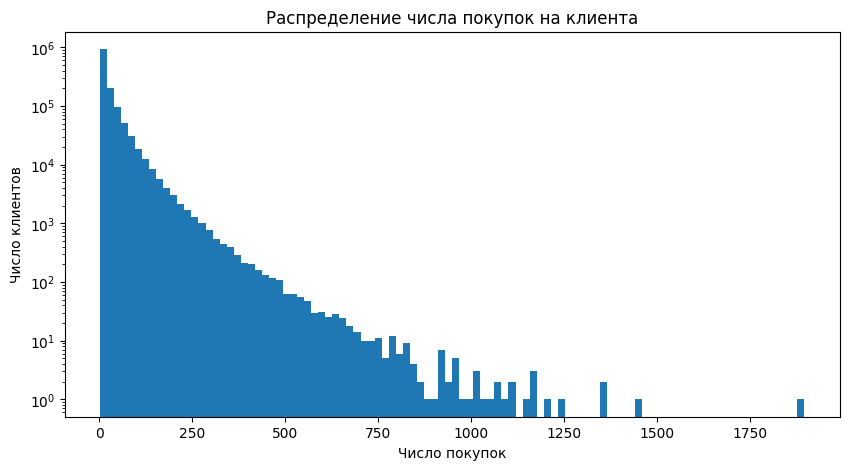

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(purchases_per_customer, bins=100, log=True)
plt.title("Распределение числа покупок на клиента")
plt.xlabel("Число покупок")
plt.ylabel("Число клиентов")
plt.show()


Распределение числа покупок на клиента имеет выраженный длинный хвост, для визуализации массового поведения используем  диапазон значений от 1 до 30. Клиентов с большой лояльностью к компании анализируем отдельно, чтобы не искажать интерпретацию основной части распределения.

Большая доля клиентов совершает только одну покупку, что характерно для индустрии быстрой моды. При этом существует небольшой сегмент клиентов с большим числом покупок, формирующий длинный хвост распределения. Это указывает на потенциальную неоднородность удержания между когортами и сегментами клиентов.